In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [74]:
# Clusters represent latent passenger types, e.g.:

# Cluster A → Poor class, low fare, 3rd class, young males

# Cluster B → Rich class, high fare, 1st class families

# Cluster C → Middle class mixed group

In [75]:
import pandas as pd

df = pd.read_csv("train.csv")

# Drop irrelevant columns
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# Separate target (not for clustering)
y = df['Survived']
df = df.drop(columns=['Survived'])

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  889 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB
None


In [76]:
df['Embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [77]:
# Age → median (robust to outliers)
df['Age'].fillna(df['Age'].median(), inplace=True)

# Embarked → mode (most frequent category)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

print(df.isnull().sum())

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


C:\Users\Omkar Raut\AppData\Local\Temp\ipykernel_16036\85927265.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [78]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])         # male/female → 0/1
df['Embarked'] = le.fit_transform(df['Embarked'])  # C,Q,S → 0,1,2

print(df.head())

   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0       3    1  22.0      1      0   7.2500         2
1       1    0  38.0      1      0  71.2833         0
2       3    0  26.0      0      0   7.9250         2
3       1    0  35.0      1      0  53.1000         2
4       3    1  35.0      0      0   8.0500         2


In [79]:
# Family size = SibSp + Parch + 1 (self)

In [80]:
df.dtypes

Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object

In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print(X_scaled.shape)

(891, 7)


In [82]:
df.shape

(891, 7)

In [83]:
X_scaled

array([[ 0.82737724,  0.73769513, -0.56573646, ..., -0.47367361,
        -0.50244517,  0.58595414],
       [-1.56610693, -1.35557354,  0.66386103, ..., -0.47367361,
         0.78684529, -1.9423032 ],
       [ 0.82737724, -1.35557354, -0.25833709, ..., -0.47367361,
        -0.48885426,  0.58595414],
       ...,
       [ 0.82737724, -1.35557354, -0.1046374 , ...,  2.00893337,
        -0.17626324,  0.58595414],
       [-1.56610693,  0.73769513, -0.25833709, ..., -0.47367361,
        -0.04438104, -1.9423032 ],
       [ 0.82737724,  0.73769513,  0.20276197, ..., -0.47367361,
        -0.49237783, -0.67817453]])

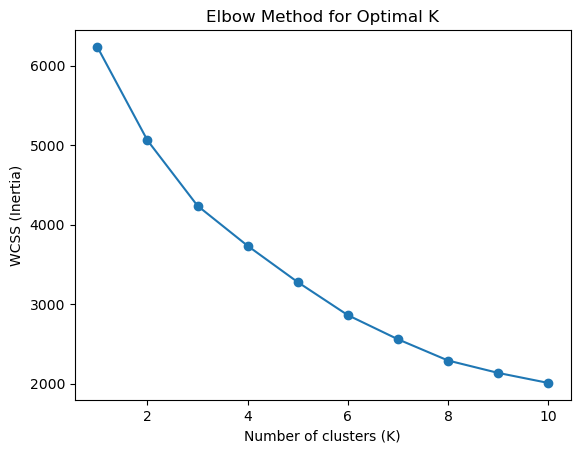

In [84]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)   # loss J ; inerti_ => wcss value

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal K")
plt.show()

In [85]:
from sklearn.cluster import KMeans

k = 3
kmeans = KMeans(n_clusters=k, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [86]:
clusters

array([0, 1, 2, 1, 0, 0, 1, 2, 2, 2, 2, 1, 0, 2, 2, 1, 2, 0, 2, 2, 0, 0,
       2, 1, 2, 2, 0, 1, 2, 0, 1, 1, 2, 0, 1, 1, 0, 0, 2, 2, 2, 2, 0, 2,
       2, 0, 0, 2, 0, 2, 2, 0, 1, 2, 1, 1, 2, 0, 2, 2, 0, 1, 1, 2, 1, 0,
       2, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 2, 1, 2, 2, 2, 0,
       1, 0, 0, 0, 1, 2, 0, 0, 1, 1, 2, 0, 2, 0, 1, 0, 0, 0, 2, 0, 0, 2,
       1, 2, 0, 2, 2, 0, 0, 0, 1, 2, 0, 0, 0, 2, 1, 0, 0, 0, 2, 0, 0, 0,
       2, 2, 0, 0, 2, 1, 0, 1, 2, 2, 2, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0,
       0, 1, 2, 0, 0, 2, 0, 2, 0, 0, 2, 2, 1, 2, 1, 0, 1, 2, 2, 0, 1, 0,
       2, 1, 0, 0, 2, 0, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0, 2, 2, 1, 1, 0, 0,
       2, 2, 0, 2, 0, 0, 0, 2, 0, 0, 2, 1, 0, 2, 0, 0, 0, 1, 2, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 1, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2,
       0, 0, 0, 1, 2, 2, 1, 0, 0, 2, 1, 0, 2, 2, 1, 1, 1, 2, 0, 2, 1, 1,
       2, 0, 2, 0, 1, 1, 1, 0, 2, 1, 2, 1, 0, 0, 2, 2, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 2, 1, 1, 0, 2, 0, 1, 0, 2, 1, 1, 2,

In [87]:
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Cluster
0,3,1,22.0,1,0,7.2500,2,0
1,1,0,38.0,1,0,71.2833,0,1
2,3,0,26.0,0,0,7.9250,2,2
3,1,0,35.0,1,0,53.1000,2,1
4,3,1,35.0,0,0,8.0500,2,0


In [88]:
kmeans.cluster_centers_

array([[ 0.53619912,  0.72750891,  0.02053248, -0.3111801 , -0.40420894,
        -0.40643886,  0.17380514],
       [-1.52696116, -0.18177802,  0.66580742, -0.09295421, -0.07924073,
         1.02733709, -0.4418888 ],
       [ 0.39996936, -0.97784085, -0.56737458,  0.55559107,  0.68829845,
        -0.1985104 ,  0.08695598]])

In [89]:
print(df.groupby('Cluster'))

In [90]:
# 🔹 SibSp
# Siblings/Spouses aboard
# → Number of brothers, sisters, or spouse traveling with the passenger.

# 🔹 Parch
# Parents/Children aboard
# → Number of parents or children traveling with the passenger.

In [91]:
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)
# cluster 0 -> Poor, young, male, solo travelers
# cluster 1 ->Wealthy, first-class, family travelers
# cluster 2 -> Young females with families, mid/low class

           Pclass       Sex        Age     SibSp     Parch       Fare  \
Cluster                                                                 
0        2.756691  0.995134  29.628759  0.180049  0.055961  12.018205   
1        1.032710  0.560748  38.025327  0.420561  0.317757  83.227454   
2        2.642857  0.180451  21.978684  1.135338  0.936090  22.345083   

         Embarked  
Cluster            
0        1.673966  
1        1.186916  
2        1.605263  


In [92]:
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Cluster
0,3,1,22.0,1,0,7.2500,2,0
1,1,0,38.0,1,0,71.2833,0,1
2,3,0,26.0,0,0,7.9250,2,2
3,1,0,35.0,1,0,53.1000,2,1
4,3,1,35.0,0,0,8.0500,2,0


In [93]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=3,        # same K as K-Means for comparison
    linkage='ward'       # variance-minimizing
)

h_labels = agg.fit_predict(X_scaled)

df['H_Cluster'] = h_labels

In [94]:
h_summary = df.groupby('H_Cluster').mean()
print(h_summary)

             Pclass       Sex        Age     SibSp     Parch        Fare  \
H_Cluster                                                                  
0          2.436242  0.671141  29.366000  0.302013  0.308725   21.215368   
1          1.088235  0.529412  36.220588  0.470588  0.401961  110.165931   
2          2.977273  0.522727  13.386364  4.386364  1.568182   37.535798   

           Embarked   Cluster  
H_Cluster                      
0          1.697987  0.754362  
1          0.196078  0.941176  
2          1.909091  2.000000  


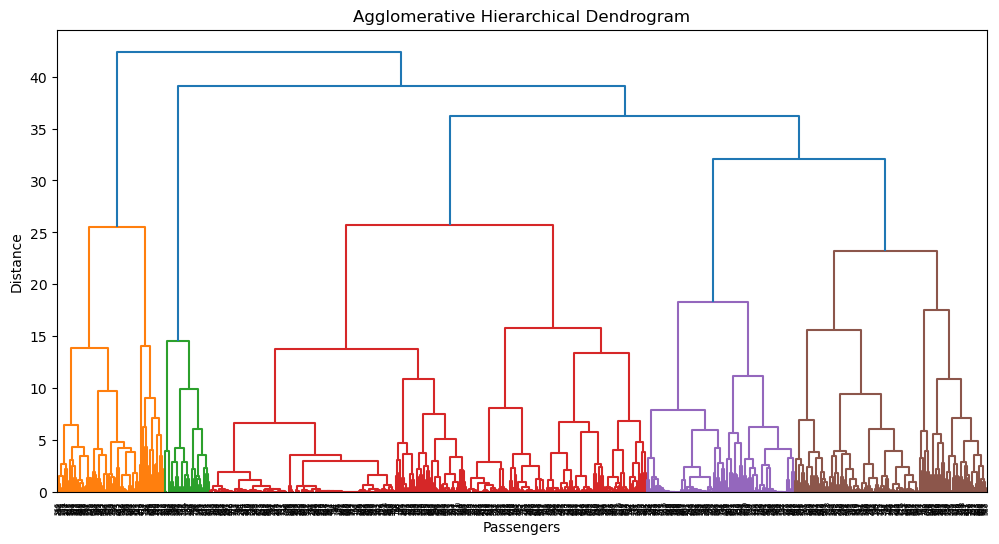

In [95]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12,6))
dendrogram(Z)
plt.title("Agglomerative Hierarchical Dendrogram")
plt.xlabel("Passengers")
plt.ylabel("Distance")
plt.show()